## Bayesian Estimation Spearman Correlation

In [1]:
import pandas as pd
import numpy as np

seeds = [42,0,1,2,3]
cancers = ["ccRCC", "Melanoma","NSCLC"]
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
Cancer_spearman_dict = {}
for cancer in cancers:
    score_dict_spearman = {}
    for seed in seeds:
        if cancer == 'ccRCC':
            spearman_seed = pd.read_csv(f"../ccRCC/NarrowUtility/DGE/DGE_Nivo/Seed_{seed}/Spearman_{seed}_NivoBenefit.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
        if cancer == 'Melanoma':
            spearman_seed = pd.read_csv(f"../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/Spearman_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']
        if cancer == 'NSCLC':
            spearman_seed = pd.read_csv(f"../NSCLC/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/Spearman_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
        scores = spearman_seed['Spearman_rho'].clip(lower=0).values.tolist()
        score_dict_spearman[seed] = scores
    df_cancer = pd.DataFrame(score_dict_spearman, index = algo).T
    Cancer_spearman_dict[cancer] = df_cancer

/tmp/ipykernel_304208/14859697.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/tmp/ipykernel_304208/14859697.py:44: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  g = sns.catplot(


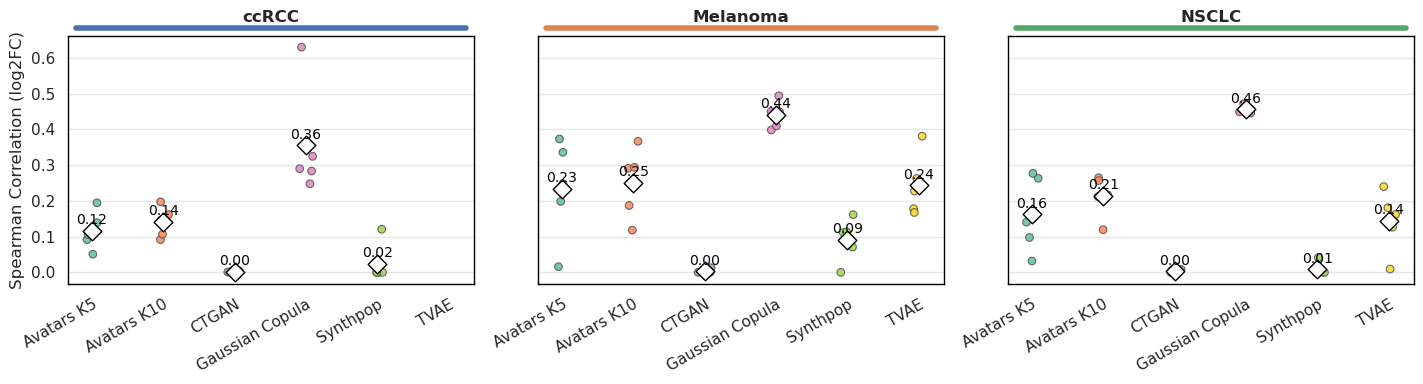

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Color consistency (manuscript) ---
CANCER_COLORS = {
    "ccRCC": "#4C72B0",
    "Melanoma": "#DD8452",
    "NSCLC": "#55A868",
}
DATASET_COLORS = {
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

rows = []
for cancer, df_wide in Cancer_spearman_dict.items():
    df_tmp = df_wide.copy()
    df_tmp.index.name = "Seed"
    df_long = df_tmp.reset_index().melt(
        id_vars="Seed",
        var_name="Dataset",
        value_name="Spearman_rho",
    )
    df_long["Cancer"] = cancer
    rows.append(df_long)

df_long = pd.concat(rows, ignore_index=True)
df_long["Spearman_rho"] = pd.to_numeric(df_long["Spearman_rho"], errors="coerce")
df_long = df_long[np.isfinite(df_long["Spearman_rho"])]


cancer_order = ["ccRCC", "Melanoma", "NSCLC"]
dataset_order = [d for d in DATASET_COLORS.keys() if d in df_long["Dataset"].unique()]

df_long["Cancer"] = pd.Categorical(df_long["Cancer"], categories=cancer_order, ordered=True)
df_long["Dataset"] = pd.Categorical(df_long["Dataset"], categories=dataset_order, ordered=True)


sns.set(style="whitegrid", rc={"grid.color": "#e6e6e6"})
g = sns.catplot(
    data=df_long,
    x="Dataset",
    y="Spearman_rho",
    col="Cancer",
    col_order=cancer_order,
    kind="strip",
    order=dataset_order,
    palette=DATASET_COLORS,   # dataset colors (consistent across cancers)
    jitter=True,
    size=5.5,
    alpha=0.9,
    edgecolor="gray",
    linewidth=0.8,
    height=4.0,
    aspect=1.2,
    sharey=True,
)


for ax, cancer in zip(g.axes.flat, cancer_order):
    if cancer not in df_long["Cancer"].unique():
        continue

    sub = df_long[df_long["Cancer"] == cancer]
    means = sub.groupby("Dataset", observed=True)["Spearman_rho"].mean().reindex(dataset_order)

    for i, (dataset, mu) in enumerate(means.items()):
        if pd.isna(mu):
            continue
        ax.scatter(
            i,
            mu,
            marker="D",
            color="white",
            edgecolor="black",
            s=90,
            zorder=10,
        )
        ax.text(
            i,
            mu + 0.01,
            f"{mu:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="black",
            zorder=11,
        )

    # colored strip under title (cancer identity)
    ax.plot(
        [0.02, 0.98],
        [1.03, 1.03],
        transform=ax.transAxes,
        color=CANCER_COLORS.get(cancer, "#333333"),
        lw=4,
        clip_on=False,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Spearman Correlation (log2FC)")
    ax.set_title(cancer, fontsize=12, fontweight="bold", pad=10)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment("right")
        label.set_rotation_mode("anchor")

for ax in g.axes.flat:
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")

g.fig.savefig("spearman_log2fc.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [19]:
rows = []
n_reps = 5
for cancer, method_to_scores in Cancer_spearman_dict.items():
    for method, scores in method_to_scores.items():
        scores = np.asarray(scores, dtype=float)
        scores = scores[np.isfinite(scores)]  # drop NaN/inf if any

        row = {
            "Cancer": cancer,
            "Methods": method,
        }
        for i in range(n_reps):
            row[f"Replicate {i+1}"] = float(scores[i]) if i < scores.size else np.nan

        rows.append(row)

df_separman = pd.DataFrame(
    rows,
    columns=["Cancer", "Methods"] + [f"Replicate {i+1}" for i in range(n_reps)],
)
df_separman = df_separman.round(2)
df_separman.to_csv('spearman_log2fc.csv', index = False)